# Pricer and Greeks

This notebook runs `pricing.py` and `greeks.py`, the two modules the rest of the project is built on. Everything here is pure functions. There is no market data and nothing needs internet.

In [1]:
import sys

sys.path.insert(0, "..")  # optionsengine lives one level up, next to notebooks/

import numpy as np
import matplotlib.pyplot as plt
from optionsengine.pricing import bs_price, forward_price
from optionsengine.greeks import all_greeks, delta, gamma, vega, theta
from optionsengine.config import r

## The model

This is plain Black-Scholes. The option is a European call or put. The underlying pays no dividends, and both the volatility and the interest rate are constant.

$$
C = S \, N(d_1) - K e^{-rT} N(d_2) \qquad\qquad
P = K e^{-rT} N(-d_2) - S \, N(-d_1)
$$

$$
d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)\,T}{\sigma\sqrt{T}} \qquad\qquad
d_2 = d_1 - \sigma\sqrt{T}
$$

$N$ is the standard normal CDF. $S$ is the spot price, $K$ the strike, $T$ the time to expiry in years, $r$ the risk-free rate, and $\sigma$ the volatility.

## Check against a textbook

Hull's *Options, Futures and Other Derivatives* has a worked example: spot 42, strike 40, six months to expiry, 10% rate, 20% vol. The book gives a call price of 4.76 and a put price of 0.81.

In [2]:
call = bs_price(S=42, K=40, T=0.5, r=0.10, sigma=0.20, option_type="call")
put = bs_price(S=42, K=40, T=0.5, r=0.10, sigma=0.20, option_type="put")
print(f"call = {call:.2f}  (Hull: 4.76)")
print(f"put  = {put:.2f}  (Hull: 0.81)")

call = 4.76  (Hull: 4.76)
put  = 0.81  (Hull: 0.81)


## Put-call parity

For any inputs, $C - P = S - Ke^{-rT}$. This is a no-arbitrage result. It does not depend on the Black-Scholes formula, so it checks the call and put prices against each other without assuming the model that produced them.

In [3]:
lhs = call - put
rhs = 42 - 40 * np.exp(-0.10 * 0.5)
print(f"C - P          = {lhs:.6f}")
print(f"S - K*exp(-rT) = {rhs:.6f}")

C - P          = 3.950823
S - K*exp(-rT) = 3.950823


## Price against strike

From here on the notebook uses one running example: spot 7700, which is roughly today's SPX level, six months to expiry, 18% vol. The strikes are centred on the forward price $F = Se^{rT}$ rather than on spot. This is the same "at the money" convention the rest of the project uses.

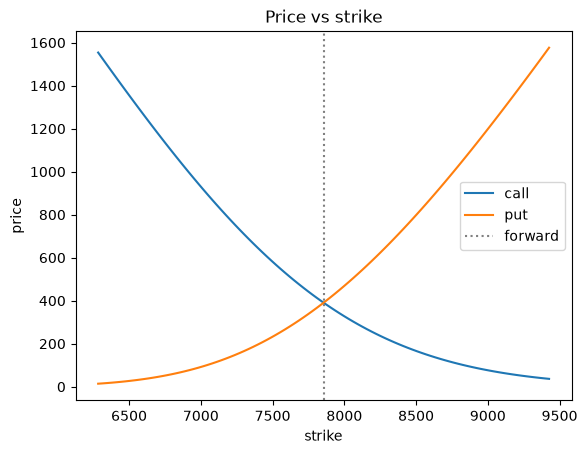

In [4]:
S, T, sigma = 7700.0, 0.5, 0.18
F = forward_price(S, T, r)
strikes = np.linspace(0.8 * F, 1.2 * F, 100)  # same moneyness window the live chain uses

call_prices = [bs_price(S, K, T, r, sigma, "call") for K in strikes]
put_prices = [bs_price(S, K, T, r, sigma, "put") for K in strikes]

fig, ax = plt.subplots()
ax.plot(strikes, call_prices, label="call")
ax.plot(strikes, put_prices, label="put")
ax.axvline(F, linestyle=":", color="grey", label="forward")
ax.set_title("Price vs strike")
ax.set_xlabel("strike")
ax.set_ylabel("price")
ax.legend()
plt.show()

## Two edge cases

`bs_price` treats zero volatility and zero time separately, so the formula never divides by zero.

- **$T = 0$.** The option has expired. It is worth its intrinsic value, $\max(S - K, 0)$.
- **$\sigma = 0$.** There is no uncertainty left, so the payoff is already known. It is not paid until expiry, so the strike is discounted: $\max(S - Ke^{-rT}, 0)$, not $\max(S - K, 0)$. The IV solver relies on this, because it is the solver's lower bound.

In [5]:
K = 7800.0
print("T = 0,     call:", bs_price(S, K, 0.0, r, sigma, "call"),
      " vs raw intrinsic       ", max(S - K, 0.0))
print("sigma = 0, call:", bs_price(S, K, T, r, 0.0, "call"),
      " vs discounted intrinsic", max(S - K * np.exp(-r * T), 0.0))

T = 0,     call: 0.0  vs raw intrinsic        0.0
sigma = 0, call: 54.45034820730871  vs discounted intrinsic 54.45034820730871


## Greeks

Each Greek is the derivative of the price with respect to one input.

$$
\Delta = \frac{\partial V}{\partial S} \qquad
\Gamma = \frac{\partial^2 V}{\partial S^2} \qquad
\nu = \frac{\partial V}{\partial \sigma} \qquad
\Theta = \frac{\partial V}{\partial T} \qquad
\rho = \frac{\partial V}{\partial r}
$$

Gamma and vega do not take an option type. A call and a put with the same strike and expiry differ only by a forward. A forward is a straight line in $S$ with no volatility in it. So the curvature in $S$ and the sensitivity to $\sigma$ have to be the same for both. The table below shows this.

In [6]:
K_atm = F  # at the money means K = F, not K = S
g_call = all_greeks(S, K_atm, T, r, sigma, "call")
g_put = all_greeks(S, K_atm, T, r, sigma, "put")

print(f"{'':8}{'call':>12}{'put':>12}")
for name in ("delta", "gamma", "vega", "theta", "rho"):
    print(f"{name:<8}{getattr(g_call, name):12.4f}{getattr(g_put, name):12.4f}")

                call         put
delta         0.5254     -0.4746
gamma         0.0004      0.0004
vega       2167.7358   2167.7358
theta      -536.3780   -228.3780
rho        1827.3201  -2022.6799


## Greeks against strike

Delta runs from 0 to 1 for a call, and from -1 to 0 for a put, in an S-shape. Gamma and vega both peak at the money and fall off on either side. They are proportional for fixed spot, time and vol, with $\nu = \Gamma \cdot S^2 \sigma T$, so the two plots below have the same shape. Theta is usually most negative near the money, because that is where the option has the most time value to lose.

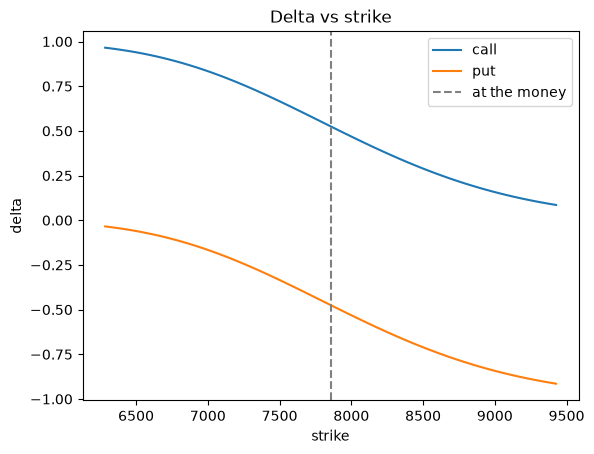

In [7]:
deltas_call = [delta(S, K, T, r, sigma, "call") for K in strikes]
deltas_put = [delta(S, K, T, r, sigma, "put") for K in strikes]

fig, ax = plt.subplots()
ax.plot(strikes, deltas_call, label="call")
ax.plot(strikes, deltas_put, label="put")
ax.axvline(F, linestyle="--", color="grey", label="at the money")
ax.set_title("Delta vs strike")
ax.set_xlabel("strike")
ax.set_ylabel("delta")
ax.legend()
plt.show()

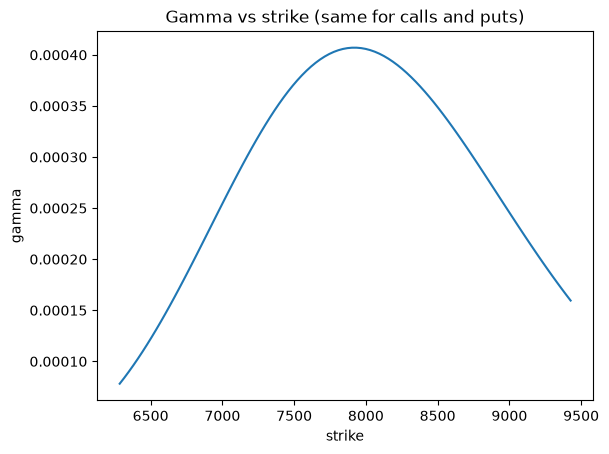

In [8]:
gammas = [gamma(S, K, T, r, sigma) for K in strikes]

fig, ax = plt.subplots()
ax.plot(strikes, gammas)
ax.set_title("Gamma vs strike (same for calls and puts)")
ax.set_xlabel("strike")
ax.set_ylabel("gamma")
plt.show()

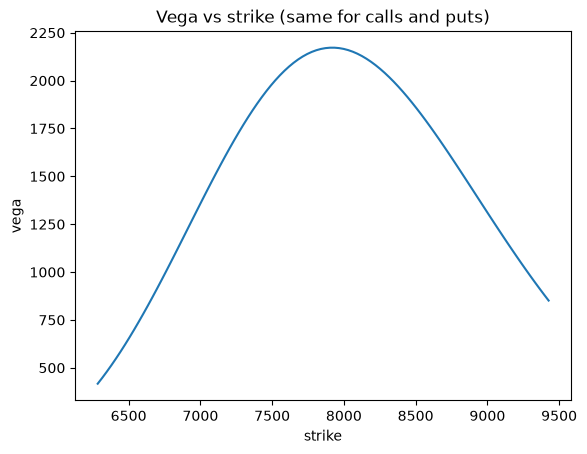

In [9]:
vegas = [vega(S, K, T, r, sigma) for K in strikes]

fig, ax = plt.subplots()
ax.plot(strikes, vegas)
ax.set_title("Vega vs strike (same for calls and puts)")
ax.set_xlabel("strike")
ax.set_ylabel("vega")
plt.show()

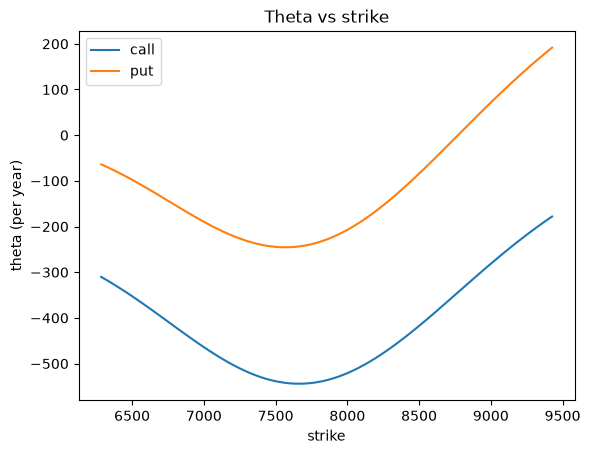

In [10]:
thetas_call = [theta(S, K, T, r, sigma, "call") for K in strikes]
thetas_put = [theta(S, K, T, r, sigma, "put") for K in strikes]

fig, ax = plt.subplots()
ax.plot(strikes, thetas_call, label="call")
ax.plot(strikes, thetas_put, label="put")
ax.set_title("Theta vs strike")
ax.set_xlabel("strike")
ax.set_ylabel("theta (per year)")
ax.legend()
plt.show()

## Time decay speeds up near expiry

This is the same at-the-money option, with theta plotted against time to expiry instead of strike. The closer the option gets to expiry, the more value it loses each day. The decay does not continue at a steady rate. It accelerates.

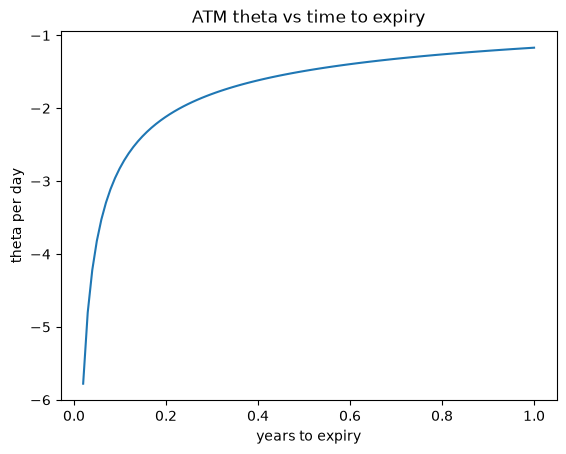

In [11]:
times = np.linspace(0.02, 1.0, 100)
thetas_atm = [theta(S, S, T_i, r, sigma, "call") / 365 for T_i in times]  # per day

fig, ax = plt.subplots()
ax.plot(times, thetas_atm)
ax.set_title("ATM theta vs time to expiry")
ax.set_xlabel("years to expiry")
ax.set_ylabel("theta per day")
plt.show()

## Check against finite differences

This is the same approach the test suite uses. Bump one input to the price function, re-price, and compare the result to the closed-form Greek. It does not reuse any of the algebra in `greeks.py`, so a sign error or a missing $e^{-rT}$ would show up here.

In [12]:
def fd_delta(S, K, T, r, sigma, option_type, h=1e-4):
    return (bs_price(S + h, K, T, r, sigma, option_type)
            - bs_price(S - h, K, T, r, sigma, option_type)) / (2 * h)


def fd_gamma(S, K, T, r, sigma, option_type, h=1e-3):
    return (bs_price(S + h, K, T, r, sigma, option_type)
            - 2 * bs_price(S, K, T, r, sigma, option_type)
            + bs_price(S - h, K, T, r, sigma, option_type)) / h**2


def fd_vega(S, K, T, r, sigma, option_type, h=1e-4):
    return (bs_price(S, K, T, r, sigma + h, option_type)
            - bs_price(S, K, T, r, sigma - h, option_type)) / (2 * h)


print(f"delta  closed {g_call.delta:.6f}  finite-diff {fd_delta(S, K_atm, T, r, sigma, 'call'):.6f}")
print(f"gamma  closed {g_call.gamma:.6f}  finite-diff {fd_gamma(S, K_atm, T, r, sigma, 'call'):.6f}")
print(f"vega   closed {g_call.vega:.6f}  finite-diff {fd_vega(S, K_atm, T, r, sigma, 'call'):.6f}")

delta  closed 0.525371  finite-diff 0.525371
gamma  closed 0.000406  finite-diff 0.000406
vega   closed 2167.735784  finite-diff 2167.735784


## Next

`02_iv_solver.ipynb` runs `implied_vol.py` on a real SPX snapshot. It looks at the split between Newton and bisection, where each method is used, and why.